In [1]:
import numpy as np
import pandas as pd
from IPython.display import display

FULL_DATA_PATH = "../../../data/processed/processed_joined_dataset.csv"
SAMPLE_DATA_PATH = "../../../data/processed/sample.csv"

USE_FULL_DATA = False              # change to True for the full joined dataset
TREE_MAX_DEPTH = 4
TREE_MIN_SAMPLES_LEAF = 200

data_path = FULL_DATA_PATH if USE_FULL_DATA else SAMPLE_DATA_PATH
print("Using:", data_path)

Using: ../../../data/processed/sample.csv


In [2]:
df = pd.read_csv(data_path, sep="|")
print("Shape:", df.shape)
print(df.shape)
display(df.head())
display(df.info())
display(df.describe().T)
display(df.isna().sum().sort_values(ascending=False))
display(df.nunique().sort_values())

Shape: (200000, 29)
(200000, 29)


,lineID,day,pid,adFlag,availability,competitorPrice,click,basket,order,price,...,rrp,has_competitor,campaignIndex_A,campaignIndex_B,campaignIndex_C,price_diff_competitor,price_ratio_competitor,price_pct_diff_competitor,is_post_shift_day,price_diff_vs_previous_available_day
0,978899,39,9624,0,1,17.19,1,0,0,19.89,...,21.51,1,0,0,0,2.70,1.1571,15.71,1,0.0
1,1267035,47,3969,1,1,18.13,1,0,0,20.85,...,26.07,1,0,0,0,2.72,1.1500,15.00,1,0.0
2,297914,14,16633,0,1,15.06,0,0,1,16.45,...,23.98,1,0,1,0,1.39,1.0923,9.23,0,0.0
3,2554963,87,20147,0,1,4.36,1,0,0,5.17,...,5.45,1,0,0,0,0.81,1.1858,18.58,1,0.0
4,2739211,92,14326,0,1,NaN,0,0,1,6.22,...,6.55,0,0,0,0,NaN,NaN,NaN,1,0.0


<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 29 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   lineID                                200000 non-null  int64  
 1   day                                   200000 non-null  int64  
 2   pid                                   200000 non-null  int64  
 3   adFlag                                200000 non-null  int64  
 4   availability                          200000 non-null  int64  
 5   competitorPrice                       192805 non-null  float64
 6   click                                 200000 non-null  int64  
 7   basket                                200000 non-null  int64  
 8   order                                 200000 non-null  int64  
 9   price                                 200000 non-null  float64
 10  revenue                               200000 non-null  float64
 11  manufacture

None

,count,mean,std,min,25%,50%,75%,max
lineID,200000.0,1.377866e+06,795476.869749,64.0000,689267.5000,1.377566e+06,2.066244e+06,2756002.000
day,200000.0,4.991622e+01,25.292519,1.0000,31.0000,5.000000e+01,7.100000e+01,92.000
pid,200000.0,1.043976e+04,6448.469978,3.0000,4315.0000,1.005700e+04,1.613800e+04,22035.000
adFlag,200000.0,3.171400e-01,0.465364,0.0000,0.0000,0.000000e+00,1.000000e+00,1.000
availability,200000.0,1.110030e+00,0.391170,1.0000,1.0000,1.000000e+00,1.000000e+00,4.000
competitorPrice,192805.0,1.275064e+01,12.704603,0.0700,5.4700,8.990000e+00,1.506000e+01,238.670
click,200000.0,5.740400e-01,0.494489,0.0000,0.0000,1.000000e+00,1.000000e+00,1.000
basket,200000.0,1.701050e-01,0.375726,0.0000,0.0000,0.000000e+00,0.000000e+00,1.000
order,200000.0,2.558550e-01,0.436342,0.0000,0.0000,0.000000e+00,1.000000e+00,1.000
price,200000.0,1.380901e+01,13.612293,0.0700,6.0000,9.850000e+00,1.645000e+01,374.590


competitorPrice                         7195
price_pct_diff_competitor               7195
price_diff_competitor                   7195
price_ratio_competitor                  7195
category                                6290
price_diff_vs_previous_available_day    2653
availability                               0
basket                                     0
click                                      0
day                                        0
pid                                        0
adFlag                                     0
lineID                                     0
group                                      0
manufacturer                               0
revenue                                    0
price                                      0
order                                      0
content                                    0
pharmForm                                  0
unit                                       0
has_competitor                             0
rrp       

adFlag                                       2
basket                                       2
click                                        2
order                                        2
has_competitor                               2
campaignIndex_A                              2
campaignIndex_B                              2
genericProduct                               2
is_post_shift_day                            2
campaignIndex_C                              2
availability                                 4
salesIndex                                   4
unit                                         8
day                                         92
pharmForm                                  176
category                                   217
content                                    223
group                                      233
manufacturer                               289
price_diff_competitor                     2700
rrp                                       2934
revenue      

## Extract only relevant rows

only observations where customer bought an item should be used for predicting how much customer bought/ordered

In [3]:
df_orders = df[df["order"] == 1].copy()
df_orders["quantity_ordered"] = df_orders["revenue"] / df_orders["price"]
df_orders["quantity_ordered"].describe()

count    51171.000000
mean         1.370229
std          1.525825
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        200.000000
Name: quantity_ordered, dtype: float64

In [4]:
df_orders["quantity_ordered"].value_counts().sort_index().head(20)

quantity_ordered
1.0     40856
2.0      6855
3.0       354
3.0      1087
3.0       270
4.0       734
5.0        49
5.0       449
5.0        32
6.0        56
6.0       107
6.0        21
7.0         4
7.0        18
7.0         7
8.0        43
9.0         1
9.0        10
10.0       10
10.0      124
Name: count, dtype: int64

<Axes: >

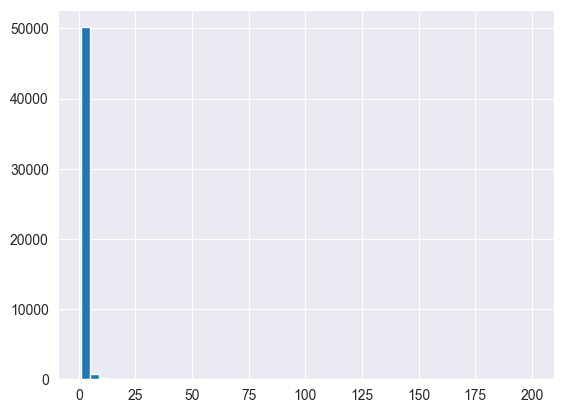

In [5]:
df_orders["quantity_ordered"].hist(bins=50)

In [6]:
df_orders[["price", "revenue", "quantity_ordered"]].sample(20)

,price,revenue,quantity_ordered
147301,1.32,5.28,4.0
136401,3.25,3.25,1.0
15035,6.00,6.00,1.0
23194,10.68,10.68,1.0
54273,5.08,5.08,1.0
175420,6.55,13.10,2.0
152000,14.25,14.25,1.0
6153,5.17,10.34,2.0
165071,16.45,16.45,1.0
162011,17.86,17.86,1.0


feature selection

In [7]:
drop_cols = [
    "lineID",                       # row ID
    "click",                        # action outcome
    "basket",                       # action outcome
    "order",                        # constant now, because we filtered order == 1
    "revenue",                      # used to calculate quantity_ordered
    "quantity_ordered",             # target
    "pid",                          # item ID
    "price_pct_diff_competitor",    # identical to price_ratio_competitor
    "price_diff_competitor",        # want to keep only price_ratio_competitor for now


]

X = df_orders.drop(columns=drop_cols)
y = df_orders["quantity_ordered"]

print(X.shape)
print(y.shape)

(51171, 21)
(51171,)


In [8]:
X.columns

Index(['day', 'adFlag', 'availability', 'competitorPrice', 'price',
       'manufacturer', 'group', 'content', 'unit', 'pharmForm',
       'genericProduct', 'salesIndex', 'category', 'rrp', 'has_competitor',
       'campaignIndex_A', 'campaignIndex_B', 'campaignIndex_C',
       'price_ratio_competitor', 'is_post_shift_day',
       'price_diff_vs_previous_available_day'],
      dtype='str')

## Next lets look closer at categorical features

In [9]:
cat_cols = ["manufacturer", "group", "unit", "pharmForm", "category"]

X[cat_cols].nunique(dropna=False).sort_values(ascending=False)

manufacturer    289
group           233
category        218
pharmForm       159
unit              8
dtype: int64

In [10]:
for col in cat_cols:
    print("\n", col)
    print(X[col].value_counts(dropna=False).head(10))


 manufacturer
manufacturer
84       3770
82       2862
52       2574
18       2241
176      1917
105      1607
other    1606
4        1477
37       1179
89       1068
Name: count, dtype: int64

 group
group
18OI0EOI    2672
22OI3       2595
2FOI        2540
other       1992
1COI00OT    1752
21OKG       1103
19OZ1ESI    1097
18OZ00IS    1096
21OK3       1069
1DOIF0ZO     851
Name: count, dtype: int64

 unit
unit
ST    25498
ML    16310
G      9088
P       190
L        57
M        20
KG        6
CM        2
Name: count, dtype: int64

 pharmForm
pharmForm
TAB        5536
FTA        4231
CRE        3545
GEL        3033
UNKNOWN    2840
LOE        2341
NAS        1908
KAP        1823
SAL        1800
HKP        1136
Name: count, dtype: int64

 category
category
50.0     3378
other    2136
66.0     1973
132.0    1731
90.0     1350
25.0     1244
101.0    1236
NaN      1156
71.0     1034
9.0       930
Name: count, dtype: int64


For first simple baseline we drop high-cardinality categorical features

In [11]:
X = X.drop(columns=[
    "manufacturer",
    "group",
    "category",
    "pharmForm"
])

print(X.shape)

(51171, 17)


### Encoding categorical features

The remaining dataset still contains one categorical feature: `unit`.
Machine learning models usually require numeric input, so this categorical column needs to be converted into numeric columns.

Because `unit` has only a small number of unique values, one-hot encoding is appropriate.
Each unit type is transformed into a separate binary column indicating whether the row belongs to that unit.

The argument `drop_first=True` removes one category to avoid creating fully redundant dummy variables.

In [12]:
X = pd.get_dummies(X, columns=["unit"], drop_first=True)

print(X.shape)
X.head()

(51171, 23)


,day,adFlag,availability,competitorPrice,price,content,genericProduct,salesIndex,rrp,has_competitor,...,price_ratio_competitor,is_post_shift_day,price_diff_vs_previous_available_day,unit_G,unit_KG,unit_L,unit_M,unit_ML,unit_P,unit_ST
2,14,0,1,15.06,16.45,50.0,0,40,23.98,1,...,1.0923,0,0.0,False,False,False,False,False,False,True
4,92,0,1,NaN,6.22,120.0,0,53,6.55,0,...,NaN,1,0.0,False,False,False,False,False,False,True
7,80,1,1,4.60,4.68,50.0,1,40,9.91,1,...,1.0174,1,0.0,False,False,False,False,False,False,True
8,21,0,1,5.38,4.97,60.0,0,53,5.38,1,...,0.9238,0,0.0,False,False,False,False,False,False,True
11,52,1,1,26.39,30.75,105.0,0,40,39.56,1,...,1.1652,1,0.0,False,False,False,False,False,False,True


### Handling missing values

After encoding the categorical feature, the dataset still contains missing values in some numeric columns.
These missing values mostly come from competitor-related features, where no competitor price was available.

Instead of removing these rows, the missing values are filled with simple neutral values:

- `competitorPrice` is filled with `0`, because no competitor price exists.
- `price_ratio_competitor` is filled with `1`, representing a neutral price ratio.
- `price_diff_vs_previous_available_day` is filled with `0`, representing no known previous price difference.

The column `has_competitor` is kept, so the model can still distinguish between real competitor information and missing competitor information.

In [13]:
X["competitorPrice"] = X["competitorPrice"].fillna(0)
X["price_ratio_competitor"] = X["price_ratio_competitor"].fillna(1)
X["price_diff_vs_previous_available_day"] = X["price_diff_vs_previous_available_day"].fillna(0)

X.isna().sum().sort_values(ascending=False).head()

day                0
adFlag             0
availability       0
competitorPrice    0
price              0
dtype: int64

### Train-test split

Before training a model, the data is split into training and testing sets.
The training set is used to fit the model, while the test set is kept separate and used only for final evaluation.

This helps check whether the model can generalize to unseen data instead of only memorizing the training data.

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(40936, 23)
(10235, 23)
(40936,)
(10235,)


### Baseline model

Before training a real regression model, a simple baseline model is created.

The baseline predicts the average `quantity_ordered` from the training set for every test observation.
This gives a minimum benchmark: a useful model should achieve lower error than this baseline.

In [15]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline_model = DummyRegressor(strategy="mean")

baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)

baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_r2 = r2_score(y_test, y_pred_baseline)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²:", baseline_r2)

Baseline MAE: 0.5806532775457806
Baseline RMSE: 1.0829745576827638
Baseline R²: -0.0003309913962947775


if we always predict the average quantity ordered, we are wrong by about 0.58 units on

### First regression model: Decision Tree

After creating the baseline, a first real regression model is trained.

A Decision Tree Regressor is used because it can capture non-linear relationships between the features and the target variable `quantity_ordered`.
It is also easier to interpret than more complex ensemble models.

The tree depth is limited with `max_depth=5` to reduce overfitting and keep the model relatively simple.

In [16]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

tree_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

tree_mae = mean_absolute_error(y_test, y_pred_tree)
tree_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tree))
tree_r2 = r2_score(y_test, y_pred_tree)

print("Decision Tree MAE:", tree_mae)
print("Decision Tree RMSE:", tree_rmse)
print("Decision Tree R²:", tree_r2)

Decision Tree MAE: 0.5302356619455397
Decision Tree RMSE: 1.3554299739634352
Decision Tree R²: -0.5669725441540656


In [17]:
results = pd.DataFrame({
    "model": ["Baseline Mean", "Decision Tree"],
    "MAE": [baseline_mae, tree_mae],
    "RMSE": [baseline_rmse, tree_rmmse if False else tree_rmse],
    "R2": [baseline_r2, tree_r2]
})

results

,model,MAE,RMSE,R2
0,Baseline Mean,0.580653,1.082975,-0.000331
1,Decision Tree,0.530236,1.355430,-0.566973
